In [4]:
import string # from some string manipulation tasks
import nltk # natural language toolkit
import re # regex
from string import punctuation # solving punctuation problems
from nltk.corpus import stopwords # stop words in sentences
from nltk.stem import WordNetLemmatizer # For stemming the sentence
from nltk.stem import SnowballStemmer # For stemming the sentence
from contractions import contractions_dict # to solve contractions
from autocorrect import Speller #correcting the spellings
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('stopwords')

#Libraries for general purpose
import matplotlib.pyplot as plt
import seaborn as sns


#Data preprocessing
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler

#Naive Bayes
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.naive_bayes import MultinomialNB

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Samson\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Samson\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Samson\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [5]:
import numpy as np
import pandas as pd

df = pd.read_csv('./cleaned_cyberbullying_tweets.csv')
df['sentiment_encoded'].value_counts()

sentiment_encoded
5    7888
0    7808
1    7697
2    7318
3    6315
Name: count, dtype: int64

In [6]:
df.head()

,text_clean,sentiment_encoded
0,word katandandre food crapilicious mkr,3
1,aussietv white mkr theblock imacelebrityau tod...,3
2,classy whore red velvet cupcake,3
3,meh thanks head concerned another angry dude t...,3
4,isi account pretending kurdish account like is...,3


Model Training

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB  # Import the Multinomial Naive Bayes classifier
from sklearn.pipeline import Pipeline
import joblib

# Define the input and target variables
X = df['text_clean']
y = df['sentiment_encoded']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline that first vectorizes the text and then applies the Naive Bayes classifier
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),  # Converts text to TF-IDF features
    ('nb', MultinomialNB())  # Multinomial Naive Bayes classifier
])

# Train the model
pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline.predict(X_test)

# Save the model to a file
joblib.dump(pipeline, 'naive_bayes_model.pkl')

# # Optionally, print the accuracy of the model on the test set
# accuracy = pipeline.score(X_test, y_test)
# print(f'Accuracy on test set: {accuracy:.4f}')

['naive_bayes_model.pkl']

In [38]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import uniform, randint  # Ensure valid distributions
import joblib

# Define the parameter grid for GridSearchCV
param_grid = {
    'tfidf__max_df': [0.7, 0.8, 0.9, 1.0],  # Maximum document frequency for the vectorizer
    'tfidf__min_df': [1, 2, 5],  # Minimum document frequency for the vectorizer (valid int values)
    'tfidf__ngram_range': [(1, 1), (1, 2)],  # Unigrams and bigrams
    'nb__alpha': [0.1, 0.5, 1.0, 2.0],  # Smoothing parameter for MultinomialNB
}

# Set up GridSearchCV
grid_search = GridSearchCV(
    pipeline,           # Our previously defined pipeline
    param_grid,         # Hyperparameters to tune
    cv=5,               # 5-fold cross-validation
    n_jobs=-1,          # Use all available cores
    verbose=1
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)
print("Best parameters from GridSearchCV:", grid_search.best_params_)
print("Best cross-validation score (GridSearchCV):", grid_search.best_score_)

# Define parameter distributions for RandomizedSearchCV
param_dist = {
    'tfidf__max_df': [0.7, 0.8, 0.9, 1.0],  # Maximum document frequency for the vectorizer
    'tfidf__min_df': uniform(0.01, 0.2),  # Use continuous uniform distribution between 0.01 and 0.2 for min_df
    'tfidf__ngram_range': [(1, 1), (1, 2)],  # Unigrams and bigrams
    'nb__alpha': uniform(0.1, 2.0),  # Uniform distribution for alpha between 0.1 and 2.0
}

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,          # Number of parameter settings sampled
    cv=5,               # 5-fold cross-validation
    n_jobs=-1,          # Use all available cores
    verbose=1,
    random_state=42
)

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)
print("Best parameters from RandomizedSearchCV:", random_search.best_params_)
print("Best cross-validation score (RandomizedSearchCV):", random_search.best_score_)

# Optionally, save the best model (from either search) for future use
# Save the best model from GridSearchCV
joblib.dump(grid_search.best_estimator_, 'naive_bayes_best_grid.pkl')
# Or save the best model from RandomizedSearchCV
joblib.dump(random_search.best_estimator_, 'naive_bayes_best_random.pkl')


Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best parameters from GridSearchCV: {'nb__alpha': 0.5, 'tfidf__max_df': 0.7, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 2)}
Best cross-validation score (GridSearchCV): 0.8717420661715056
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters from RandomizedSearchCV: {'nb__alpha': np.float64(1.7648852816008436), 'tfidf__max_df': 0.8, 'tfidf__min_df': np.float64(0.010155753168202867), 'tfidf__ngram_range': (1, 2)}
Best cross-validation score (RandomizedSearchCV): 0.8490209318028359


['naive_bayes_best_random.pkl']

Multinomial Naive Bayes Model Evaluation

In [8]:
# Load the saved model from file
loaded_model = joblib.load('naive_bayes_model.pkl')

Classification Report

In [9]:
from sklearn.metrics import classification_report


# Assuming X_test and y_test are already defined in your environment:
y_pred = loaded_model.predict(X_test)

# Generate and print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.98      0.86      1552
           1       0.89      0.92      0.91      1538
           2       0.87      0.87      0.87      1459
           3       0.86      0.39      0.54      1291
           5       0.84      0.97      0.90      1566

    accuracy                           0.84      7406
   macro avg       0.85      0.83      0.82      7406
weighted avg       0.85      0.84      0.82      7406



Confusion Matrix

Confusion Matrix:
[[1528    4    7    2   11]
 [  69 1411    5    3   50]
 [  40   46 1263   68   42]
 [ 332  106  163  506  184]
 [  16   12   14    7 1517]]


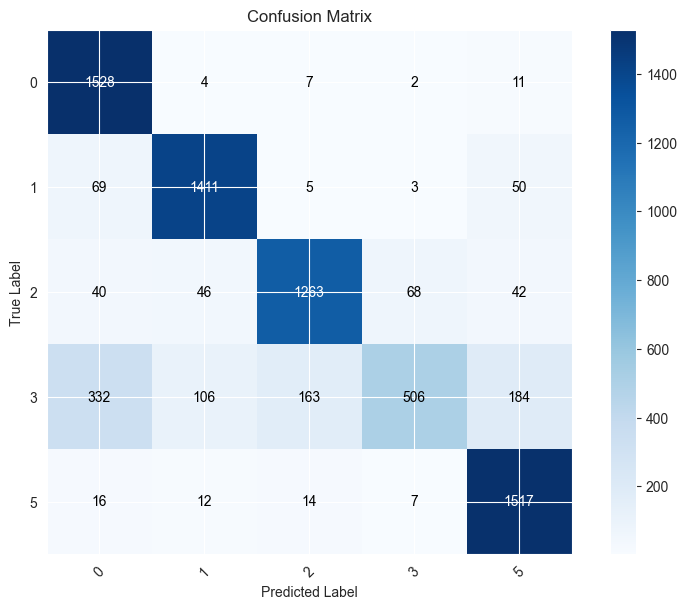

In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generate and print the confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
classes = np.unique(y_test)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# Annotate each cell with its value
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Cross Validation Score

In [11]:
from sklearn.model_selection import cross_val_score

# If you have your full dataset (X and y) available, perform cross-validation
cv_scores = cross_val_score(loaded_model, X, y, cv=5)
print("Cross Validation Scores:")
print(cv_scores)
print("Mean Cross Validation Score:", cv_scores.mean())

Cross Validation Scores:
[0.83931947 0.83565159 0.84078325 0.83848751 0.83902768]
Mean Cross Validation Score: 0.838653900892081


Prediction

In [47]:
import joblib

# 1. Load the saved model
loaded_model = joblib.load('naive_bayes_model.pkl')

# 2. Define a new piece of text to classify
new_text = "I like your content. Keep up the good work!"

# 3. Predict the sentiment
prediction = loaded_model.predict([new_text])

# 4. Print the result
print(f"Text: {new_text}")
print(f"Predicted Sentiment: {prediction[0]}")

Text: I like your content. Keep up the good work!
Predicted Sentiment: 3


Multinomial Naive Bayes Best Grid Model

In [15]:
# Load the saved model from file
loaded_model = joblib.load('naive_bayes_best_grid.pkl')

Classification Report

In [16]:
from sklearn.metrics import classification_report


# Assuming X_test and y_test are already defined in your environment:
y_pred = loaded_model.predict(X_test)

# Generate and print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1552
           1       0.92      0.94      0.93      1538
           2       0.90      0.85      0.87      1459
           3       0.79      0.60      0.68      1291
           5       0.87      0.96      0.91      1566

    accuracy                           0.87      7406
   macro avg       0.87      0.86      0.86      7406
weighted avg       0.87      0.87      0.87      7406



Confusion Matrix

Confusion Matrix:
[[1509    5    3   24   11]
 [  26 1441   11   29   31]
 [  17   40 1247  121   34]
 [ 177   71  120  769  154]
 [   5   11   12   27 1511]]


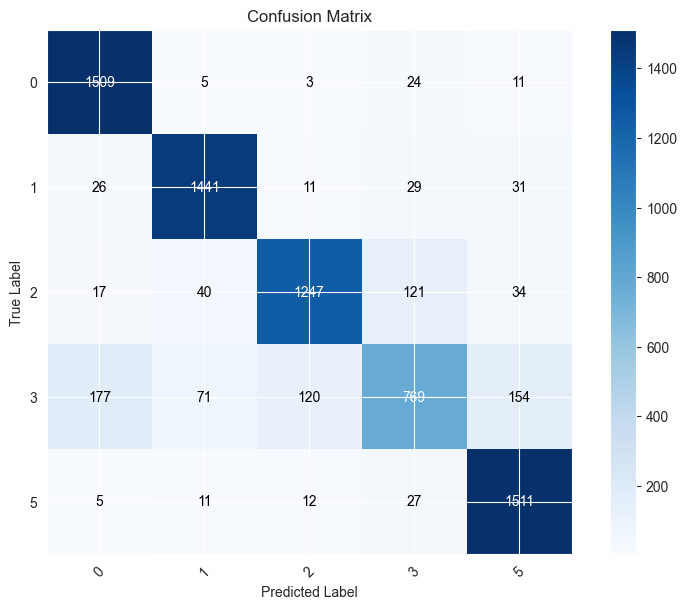

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generate and print the confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
classes = np.unique(y_test)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# Annotate each cell with its value
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Cross Validation Score

In [18]:
from sklearn.model_selection import cross_val_score

# If you have your full dataset (X and y) available, perform cross-validation
cv_scores = cross_val_score(loaded_model, X, y, cv=5)
print("Cross Validation Scores:")
print(cv_scores)
print("Mean Cross Validation Score:", cv_scores.mean())

Cross Validation Scores:
[0.87591142 0.87278866 0.8729237  0.87467927 0.87265361]
Mean Cross Validation Score: 0.8737913325746611


Prediction

In [46]:
import joblib

# 1. Load the saved model
loaded_model = joblib.load('naive_bayes_best_grid.pkl')

# 2. Define a new piece of text to classify
new_text = "I like your content. Keep up the good work!"

# 3. Predict the sentiment
prediction = loaded_model.predict([new_text])

# 4. Print the result
print(f"Text: {new_text}")
print(f"Predicted Sentiment: {prediction[0]}")

Text: I like your content. Keep up the good work!
Predicted Sentiment: 3


Multinomial Naive Bayes Best Random Model

In [21]:
# Load the saved model from file
loaded_model = joblib.load('naive_bayes_best_random.pkl')

Classification Report

In [22]:
from sklearn.metrics import classification_report


# Assuming X_test and y_test are already defined in your environment:
y_pred = loaded_model.predict(X_test)

# Generate and print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.94      0.90      1552
           1       0.94      0.93      0.94      1538
           2       0.91      0.80      0.85      1459
           3       0.66      0.58      0.62      1291
           5       0.83      0.95      0.89      1566

    accuracy                           0.85      7406
   macro avg       0.84      0.84      0.84      7406
weighted avg       0.85      0.85      0.85      7406



Confusion Matrix

Confusion Matrix:
[[1452    2    4   91    3]
 [  10 1437    8   61   22]
 [  21   24 1161  203   50]
 [ 188   54   78  750  221]
 [   8    9   21   36 1492]]


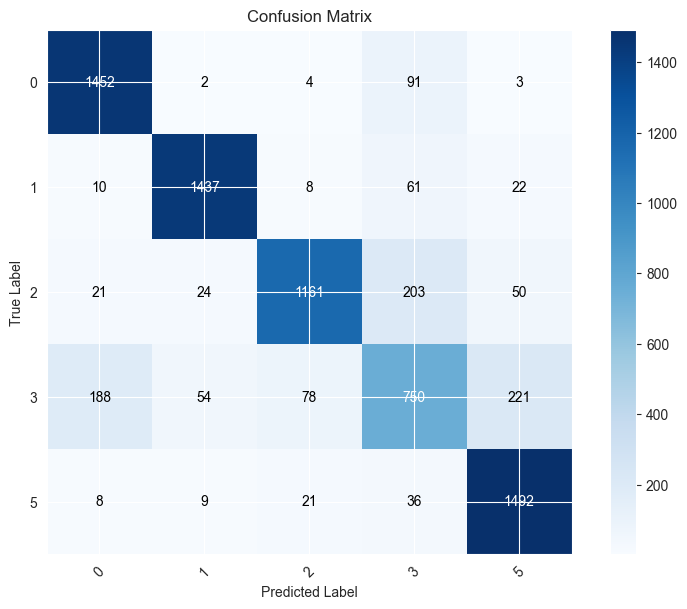

In [23]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generate and print the confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
classes = np.unique(y_test)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# Annotate each cell with its value
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Cross Validation Score

In [24]:
from sklearn.model_selection import cross_val_score

# If you have your full dataset (X and y) available, perform cross-validation
cv_scores = cross_val_score(loaded_model, X, y, cv=5)
print("Cross Validation Scores:")
print(cv_scores)
print("Mean Cross Validation Score:", cv_scores.mean())

Cross Validation Scores:
[0.8552525  0.85253207 0.84604997 0.84969615 0.84875084]
Mean Cross Validation Score: 0.8504563064821614


Prediction

In [45]:
import joblib

# 1. Load the saved model
loaded_model = joblib.load('naive_bayes_best_random.pkl')

# 2. Define a new piece of text to classify
new_text = "I like your content. Keep up the good work!"

# 3. Predict the sentiment
prediction = loaded_model.predict([new_text])

# 4. Print the result
print(f"Text: {new_text}")
print(f"Predicted Sentiment: {prediction[0]}")

Text: I like your content. Keep up the good work.
Predicted Sentiment: 3
